# Q5: Yeast Protein Interactome (YPI)

> Team: Siddhant Bali (2022496) & Siddharth Bhaskar (2022498)

In this assignment, we construct and analyze the Yeast Protein Interactome (YPI) using interaction data. We study its degree distribution, clustering behavior, identify essential proteins, and analyze robustness under node deletion strategies.

## (a) Network Construction and Analysis

We construct the YPI network from interaction data, compute its degree distribution, and analyze clustering using the C(k) × k plot.

In [67]:
# from google.colab import files
# uploaded = files.upload()

In [68]:
import networkx as nx

network_file = "Y2H_union.txt"
essential_genes_url = "https://raw.githubusercontent.com/csverma/yeast-essential-genes/master/essential_genes.txt"

def read_network(filepath):
    G = nx.Graph()
    with open(filepath, "r") as f:
        for line in f:
            u, v = line.strip().split()
            if u != v:   # no self loops
                G.add_edge(u, v)
    return G

def fetch_essential(url):
    import requests
    r = requests.get(url)
    with open("essential_genes.txt", "w") as f:
        f.write(r.text)
    essential = set()
    with open("essential_genes.txt") as f:
        for line in f:
            essential.add(line.strip())
    return essential

G = read_network(network_file)
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 1966
Edges: 2705


### Degree Distribution

We compute and plot the degree distribution of the network.

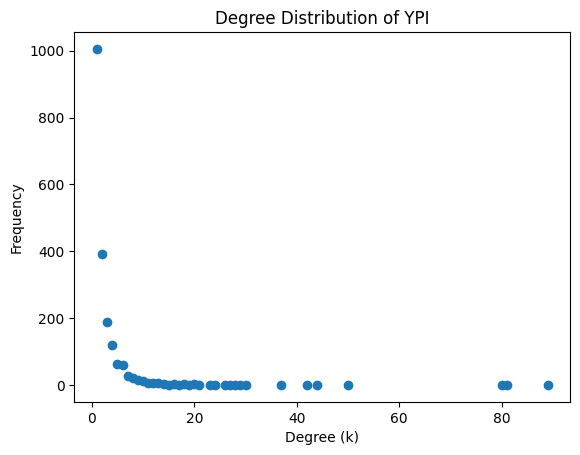

In [69]:
import matplotlib.pyplot as plt

def show_degree_plot(G, title="Degree Distribution of YPI"):
    degrees = [d for n, d in G.degree()]
    unique_deg = list(set(degrees))
    count = [degrees.count(k) for k in unique_deg]

    plt.scatter(unique_deg, count)
    plt.xlabel("Degree (k)")
    plt.ylabel("Frequency")
    plt.title(title)
    plt.show()

show_degree_plot(G)

### Clustering Coefficient Analysis

We compute C(k) and plot C(k) × k.

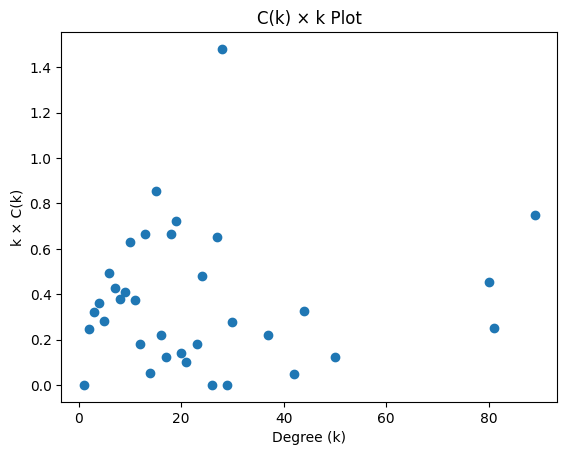

In [70]:
def plot_clustering(G):
    clustering = nx.clustering(G)

    ck = {}
    for node in G.nodes():
        k = G.degree(node)
        if k > 0:
            ck.setdefault(k, []).append(clustering[node])

    k_vals = []
    ck_vals = []

    for k in ck:
        k_vals.append(k)
        ck_vals.append(sum(ck[k]) / len(ck[k]))

    plt.scatter(k_vals, [k*c for k,c in zip(k_vals, ck_vals)])
    plt.xlabel("Degree (k)")
    plt.ylabel("k × C(k)")
    plt.title("C(k) × k Plot")
    plt.show()

plot_clustering(G)

### Network Visualization (Cytoscape)

The network can be visualized using Cytoscape by importing the edge list file. Nodes with higher degree represent hub proteins and are visually larger or differently colored.

High-degree proteins are critical as they act as hubs in the interactome.

## (b) Essential Proteins Analysis

We identify key proteins based on their degree and compute the fraction of essential proteins for each degree.

In [71]:
essential = fetch_essential(essential_genes_url)
print("Essential genes loaded")

Essential genes loaded


In [72]:
# essential genes already loaded above

In [73]:
sorted_nodes = sorted(G.degree, key=lambda x: x[1], reverse=True)

print("Top 10 proteins (hubs):")
for node, deg in sorted_nodes[:10]:
    print(node, deg)

Top 10 proteins (hubs):
YLR291C 89
YNL189W 81
YLR423C 80
YIR038C 50
YDR510W 44
YBR261C 42
YDR479C 37
YDR100W 30
YDL100C 29
YML051W 29


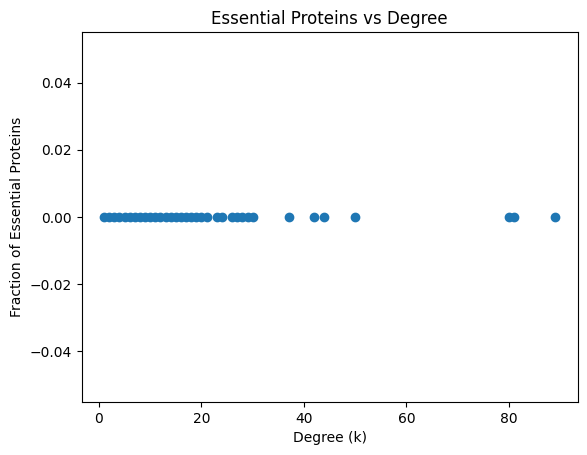

In [74]:
def plot_essentials(G, essential):
    deg_dict = dict(G.degree())

    fraction = {}
        #     if k not in fraction:
        #     fraction[k] = [0, 0]

        # if node in essential:
        #     fraction[k][0] += 1

    for node in G.nodes():
        k = deg_dict[node]

        if k not in fraction:
            fraction[k] = [0, 0]

        if node in essential:
            fraction[k][0] += 1

        fraction[k][1] += 1

    k_vals = []
    frac_vals = []

    for k in fraction:
        ess, total = fraction[k]
        k_vals.append(k)
        frac_vals.append(ess / total)

    plt.scatter(k_vals, frac_vals)
    plt.xlabel("Degree (k)")
    plt.ylabel("Fraction of Essential Proteins")
    plt.title("Essential Proteins vs Degree")
    plt.show()

plot_essentials(G, essential)

## (c) Robustness Analysis

We analyze network robustness under random and targeted node deletion strategies.

In [75]:
import random
import numpy as np

def shuffle_attack(G):
    G = G.copy()
    nodes = list(G.nodes())
    random.shuffle(nodes)

    S = []
    L = []

    for node in nodes:
        G.remove_node(node)

        if len(G) > 0:
            largest = max(nx.connected_components(G), key=len)
            S.append(len(largest) / G.number_of_nodes())
        else:
            S.append(0)

        comps = list(nx.connected_components(G))
        if len(comps) > 1:
            sizes = [len(c) for c in comps]
            L.append(np.mean(sizes))
        else:
            L.append(0)

    return S, L

def hub_attack(G):
    G = G.copy()

    nodes = sorted(G.degree, key=lambda x: x[1], reverse=True)
    nodes = [n for n, d in nodes]

    S = []
    L = []

    for node in nodes:
        G.remove_node(node)

        if len(G) > 0:
            largest = max(nx.connected_components(G), key=len)
            S.append(len(largest) / G.number_of_nodes())
        else:
            S.append(0)
        
        # comps = list(nx.connected_components(G))
        # if len(comps) > 1:
        #     sizes = [len(c) for c in comps]
        #     L.append(np.mean(sizes))
        # else:
        #     L.append(0)

        comps = list(nx.connected_components(G))
        if len(comps) > 1:
            sizes = [len(c) for c in comps]
            L.append(np.mean(sizes))
        else:
            L.append(0)

    return S, L

def show_robustness(G):
    S_rand, L_rand = shuffle_attack(G)
    S_tar, L_tar = hub_attack(G)

    plt.plot(S_rand, label="Random Attack")
    plt.plot(S_tar, label="Targeted Attack")
    plt.xlabel("Fraction of Nodes Removed")
    plt.ylabel("Largest Component Size (S)")
    plt.title("Network Robustness")
    plt.legend()
    plt.show()

In [76]:
# hub_attack already defined above

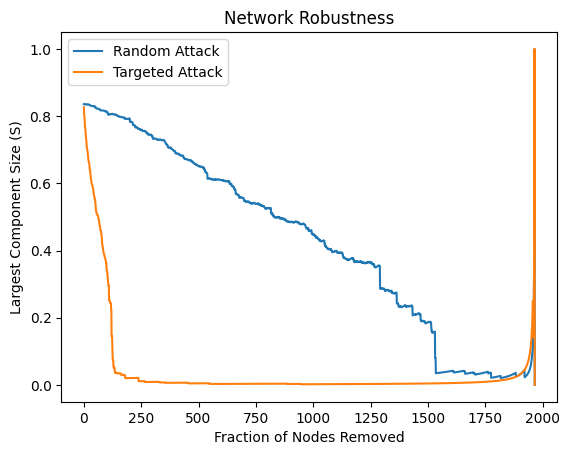

In [77]:
show_robustness(G)

## Observations

- The YPI network shows heterogeneous degree distribution, indicating presence of hub proteins.
- High-degree proteins play critical roles in maintaining network connectivity.
- The fraction of essential proteins increases with degree.
- Targeted attacks significantly disrupt the network compared to random failures.

## Conclusion

The yeast protein interactome is robust against random failures but highly vulnerable to targeted attacks on hub proteins. This highlights the biological importance of highly connected proteins.